In [ ]:
import pandas as pd

X_all = df[[
    'fck (resistência)            [MPa]',
    'Teor de fibra (%)'
]]

fr1_exp = df['fR,1 (N/mm²)      (experimental)']
fr3_exp = df['fR,3 (N/mm²)      (experimental)']

fr1_gbr = pipeline_gbr_fr1.predict(X_all)
fr3_gbr = pipeline_gbr_fr3.predict(X_all)

import pandas as pd
 


tabela_gbr = pd.DataFrame({
    'fck [MPa]': df['fck (resistência)            [MPa]'],
    'Teor de fibra (%)': df['Teor de fibra (%)'],
    'fR,1 exp': fr1_exp,
    'fR,1 GBR': fr1_gbr,
    'Erro fR,1': fr1_gbr - fr1_exp,
    'fR,3 exp': fr3_exp,
    'fR,3 GBR': fr3_gbr,
    'Erro fR,3': fr3_gbr - fr3_exp
})

import pandas as pd

pd.set_option('display.max_rows', 300)   
pd.set_option('display.max_columns', None)
 
tabela_gbr


,fck [MPa],Teor de fibra (%),"fR,1 exp","fR,1 GBR","Erro fR,1","fR,3 exp","fR,3 GBR","Erro fR,3"
0,61.30000,0.40000,4.99000,4.96060,-0.02940,3.32000,3.52767,0.20767
1,63.80000,0.80000,7.44000,7.46216,0.02216,5.68000,6.11738,0.43738
2,63.60000,0.40000,5.35000,5.21523,-0.13477,5.53000,4.44259,-1.08741
3,58.70000,0.80000,7.94000,8.08801,0.14801,8.78000,8.26406,-0.51594
4,61.30000,0.40000,5.49000,4.96060,-0.52940,3.03000,3.52767,0.49767
5,61.30000,0.40000,4.37000,4.96060,0.59060,3.28000,3.52767,0.24767
6,61.30000,0.40000,4.67000,4.96060,0.29060,2.98000,3.52767,0.54767
7,61.30000,0.40000,5.22000,4.96060,-0.25940,3.06000,3.52767,0.46767
8,61.30000,0.40000,4.74000,4.96060,0.22060,3.50000,3.52767,0.02767
9,61.30000,0.40000,5.46000,4.96060,-0.49940,4.09000,3.52767,-0.56233


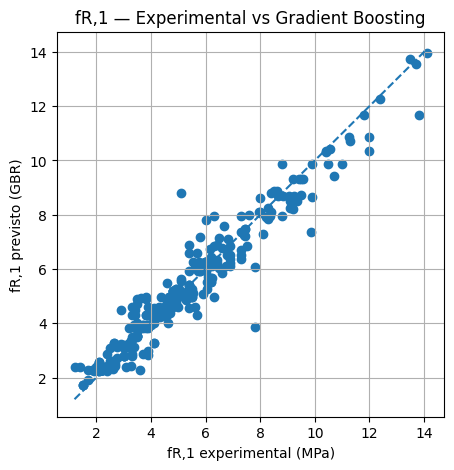

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(5,5))
plt.scatter(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR'])
plt.plot(
    [tabela_gbr['fR,1 exp'].min(), tabela_gbr['fR,1 exp'].max()],
    [tabela_gbr['fR,1 exp'].min(), tabela_gbr['fR,1 exp'].max()],
    '--'
)
plt.xlabel('fR,1 experimental (MPa)')
plt.ylabel('fR,1 previsto (GBR)')
plt.title('fR,1 — Experimental vs Gradient Boosting')
plt.grid(True)
plt.show()


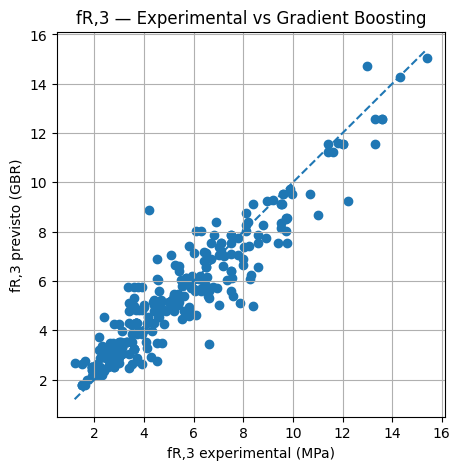

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR'])
plt.plot(
    [tabela_gbr['fR,3 exp'].min(), tabela_gbr['fR,3 exp'].max()],
    [tabela_gbr['fR,3 exp'].min(), tabela_gbr['fR,3 exp'].max()],
    '--'
)
plt.xlabel('fR,3 experimental (MPa)')
plt.ylabel('fR,3 previsto (GBR)')
plt.title('fR,3 — Experimental vs Gradient Boosting')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("GBR — fR,1")
print("MAE :", mean_absolute_error(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR']))
print("RMSE:", np.sqrt(mean_squared_error(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR'])))
print("R²  :", r2_score(tabela_gbr['fR,1 exp'], tabela_gbr['fR,1 GBR']))

print("\nGBR — fR,3")
print("MAE :", mean_absolute_error(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR']))
print("RMSE:", np.sqrt(mean_squared_error(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR'])))
print("R²  :", r2_score(tabela_gbr['fR,3 exp'], tabela_gbr['fR,3 GBR']))


GBR — fR,1
MAE : 0.4525712186611504
RMSE: 0.672657053867307
R²  : 0.930070396305028

GBR — fR,3
MAE : 0.7064883751650248
RMSE: 0.9802834108000597
R²  : 0.8767823256435324


In [118]:
# Remoção de 30% usando Linear Regression
from sklearn.linear_model import LinearRegression
import numpy as np
import pandas as pd

remove_pct = 0.30

# Treinar modelo
lin_reg = LinearRegression()
lin_reg.fit(X, y)

# Previsões
y_pred = lin_reg.predict(X)

# Erro absoluto
errors = np.abs(y - y_pred)

# Quantidade a remover
n_remove = int(len(errors) * remove_pct)

# Índices removidos
removed_idx_lr = errors.sort_values(ascending=False).head(n_remove).index

# Dataset limpo
X_clean_lr = X.drop(index=removed_idx_lr)
y_clean_lr = y.drop(index=removed_idx_lr)

print("Linear Regression")
print(f"Amostras removidas: {n_remove}")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(df.loc[removed_idx_lr])



Linear Regression
Amostras removidas: 87


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
79,BEN - 1,66.20000,50,0.62500,80.00000,1.00000,1.00000,13.80000,11.60000,10.31362,0.25264,erro alto
71,"LEE - 1,00",49.80000,60,0.92308,65.00000,1.00000,1.00000,12.00000,13.30000,8.45272,0.29561,erro alto
63,"3D-1,0",51.00000,60,0.90000,66.66667,1.00000,1.00000,12.00000,13.31000,8.61615,0.28199,erro alto
201,"TIB - 0,76",60.90000,50,0.89286,56.00000,0.76000,1.00000,10.70000,9.50000,7.26679,0.32086,erro alto
160,"MON - 1,00",63.20000,60,0.75000,80.00000,1.00000,1.00000,6.50000,5.80000,10.09172,0.55257,erro alto
218,"TIB - 1,00",25.10000,35,0.54688,64.00000,1.00000,1.00000,9.90000,7.20000,6.09986,0.38385,erro alto
88,"CUE - 0,65",61.10000,30,0.62500,48.00000,0.64583,1.00000,2.90000,2.80000,6.16248,1.12499,erro alto
84,BEN - 2,64.20000,50,0.62500,80.00000,2.00000,1.00000,13.50000,13.00000,16.78642,0.24344,erro alto
66,"ABD - 1,0",46.80000,35,0.53846,65.00000,1.00000,1.00000,5.10000,4.20000,8.20997,0.60980,erro alto
259,B403 - 27,67.70000,30,0.37999,78.95000,0.50000,1.00000,9.87000,8.90000,6.28595,0.36313,erro alto


In [119]:
#Remoção de 30% usando Random Forest
from sklearn.ensemble import RandomForestRegressor

remove_pct = 0.30

# Treinar modelo
rf = RandomForestRegressor(
    n_estimators=300,
    random_state=42
)
rf.fit(X, y)

# Previsões
y_pred = rf.predict(X)

# Erro absoluto
errors = np.abs(y - y_pred)

# Quantidade a remover
n_remove = int(len(errors) * remove_pct)

# Índices removidos
removed_idx_rf = errors.sort_values(ascending=False).head(n_remove).index

# Dataset limpo
X_clean_rf = X.drop(index=removed_idx_rf)
y_clean_rf = y.drop(index=removed_idx_rf)

print("Random Forest")
print(f"Amostras removidas: {n_remove}")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(df.loc[removed_idx_rf])


Random Forest
Amostras removidas: 87


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
160,"MON - 1,00",63.20000,60,0.75000,80.00000,1.00000,1.00000,6.50000,5.80000,10.09172,0.55257,erro alto
230,"TIB - 0,50",50.40000,60,0.80000,75.00000,0.50000,1.00000,7.80000,8.40000,5.38563,0.30954,erro alto
66,"ABD - 1,0",46.80000,35,0.53846,65.00000,1.00000,1.00000,5.10000,4.20000,8.20997,0.60980,erro alto
137,"BAR - 0,93",64.50000,60,0.92308,65.00000,0.93000,1.00000,8.80000,6.70000,9.05476,0.02895,False
218,"TIB - 1,00",25.10000,35,0.54688,64.00000,1.00000,1.00000,9.90000,7.20000,6.09986,0.38385,erro alto
88,"CUE - 0,65",61.10000,30,0.62500,48.00000,0.64583,1.00000,2.90000,2.80000,6.16248,1.12499,erro alto
147,"PER - 0,4",56.50000,60,0.75000,80.00000,0.40000,1.00000,3.50000,2.50000,4.93435,0.40981,erro alto
139,"BAR - 0,93",64.50000,60,0.92308,65.00000,0.93000,1.00000,11.00000,8.60000,9.05476,0.17684,False
260,B406 - 27,89.50000,30,0.37999,78.95000,0.50000,1.00000,10.57000,8.12000,7.16522,0.32212,erro alto
79,BEN - 1,66.20000,50,0.62500,80.00000,1.00000,1.00000,13.80000,11.60000,10.31362,0.25264,erro alto


In [120]:
#Remoção de 30% usando Gradient Boosting (o melhor modelo)
from sklearn.ensemble import GradientBoostingRegressor

remove_pct = 0.30

# Treinar modelo
gbr = GradientBoostingRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)
gbr.fit(X, y)

# Previsões
y_pred = gbr.predict(X)

# Erro absoluto
errors = np.abs(y - y_pred)

# Quantidade a remover
n_remove = int(len(errors) * remove_pct)

# Índices removidos
removed_idx_gbr = errors.sort_values(ascending=False).head(n_remove).index

# Dataset limpo
X_clean_gbr = X.drop(index=removed_idx_gbr)
y_clean_gbr = y.drop(index=removed_idx_gbr)

print("Gradient Boosting")
print(f"Amostras removidas: {n_remove}")
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

display(df.loc[removed_idx_gbr])


Gradient Boosting
Amostras removidas: 87


,Tipo do concreto,fck (resistência) [MPa],l (comprimento) [mm],d (diâmetro [mm],l/d (fator de forma,Teor de fibra (%),N (ganchos),"fR,1 (N/mm²) (experimental)","fR,3 (N/mm²) (experimental)",Unnamed: 13,Unnamed: 14,Unnamed: 15
68,"ABD - 1,0",48.20000,60,0.92308,65.00000,1.00000,1.00000,5.80000,5.10000,8.32425,0.43522,erro alto
160,"MON - 1,00",63.20000,60,0.75000,80.00000,1.00000,1.00000,6.50000,5.80000,10.09172,0.55257,erro alto
71,"LEE - 1,00",49.80000,60,0.92308,65.00000,1.00000,1.00000,12.00000,13.30000,8.45272,0.29561,erro alto
201,"TIB - 0,76",60.90000,50,0.89286,56.00000,0.76000,1.00000,10.70000,9.50000,7.26679,0.32086,erro alto
220,"TIB - 1,00",37.20000,35,0.54688,64.00000,1.00000,1.00000,9.50000,8.10000,7.33597,0.22779,erro alto
203,"TIB - 0,57",57.40000,50,0.74627,67.00000,0.57000,1.00000,7.80000,9.40000,6.07367,0.22132,erro alto
57,H34A,47.60000,60,0.75000,80.00000,0.50000,1.00000,6.23000,7.88000,5.35096,0.14110,False
139,"BAR - 0,93",64.50000,60,0.92308,65.00000,0.93000,1.00000,11.00000,8.60000,9.05476,0.17684,False
156,"BRG - 0,27",38.90000,60,0.75000,80.00000,0.27000,1.00000,1.20000,1.60000,3.11679,1.59732,erro alto
202,"TIB - 0,38",56.60000,50,0.74627,67.00000,0.38000,1.00000,5.70000,6.60000,4.49977,0.21057,erro alto
